# Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.ensemble import GradientBoostingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

## Carga do Dataset

O dataset contém informações sobre vários estudantes, com cada registro representando uma pessoa. **As variáveis incluem características médicas, medidas de saúde e a presença ou ausência de diabetes. A última coluna, Outcome, indica se a paciente tem diabetes (1) ou não (0).**

Descrição de Cada Coluna
- Pregnancies: ....

O objetivo é prever se um aluno vai finalizar a graduação ou abandonar.

In [ ]:
dataset_filename = "dataset.csv"

students_dataframe = pd.read_csv(dataset_filename, delimiter=';')

students_dataframe.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Pré-Processamento de Dados

In [12]:
## Avaliar os tipos das colunas
# students_dataframe.dtypes
# students_dataframe['Target'].unique()
students_dataframe['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [ ]:
test_size = 0.20
seed = 7

# Separação em conjuntos de treino e teste
array = students_dataframe.values
X = array[:,0:36]
y = array[:,36]
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y)

# Parâmetros e partições da validação cruzada
scoring = 'f1_weighted'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

In [49]:
print(array[4])

[2 39 1 8014 0 1 100.0 1 37 38 9 9 141.5 0 0 0 1 0 0 45 0 0 6 9 5
 12.333333333333334 0 0 6 6 6 13.0 0 13.9 -0.3 0.79 'Graduate']


## Modelagem e Inferência

### Modelos sem Padronizar ou Normalizar Dados

LR: 0.634243 (0.018891)
KNN: 0.584692 (0.030077)
CART: 0.669542 (0.020680)
NB: 0.673940 (0.012629)
SVM: 0.332551 (0.001607)
GB: 0.759260 (0.011148)


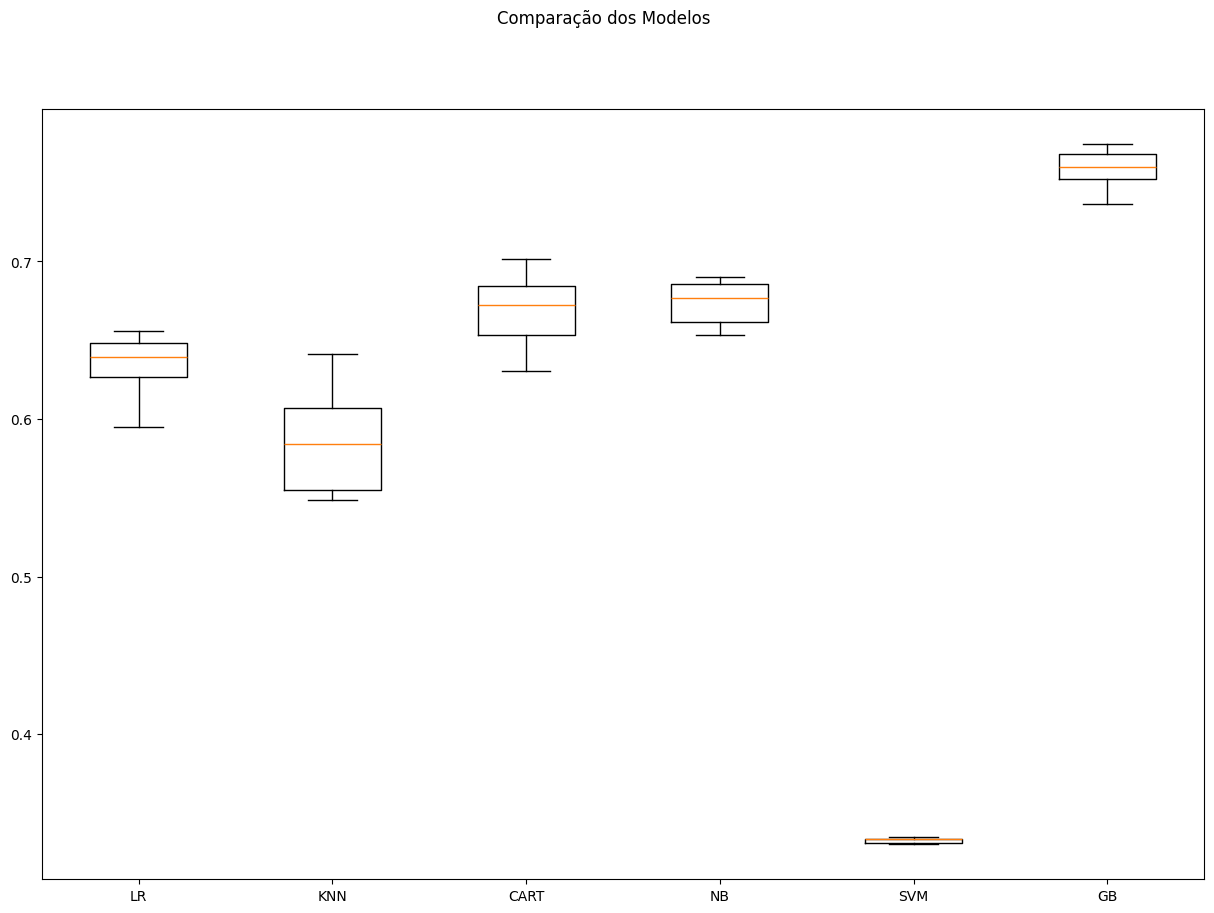

In [ ]:
np.random.seed(seed)

models = []
num_trees = 100
max_features = "sqrt"

models.append(('LR', LogisticRegression(max_iter=200))) 
models.append(('KNN', KNeighborsClassifier())) 
models.append(('CART', DecisionTreeClassifier())) 
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))

# Listas para armazenar os resultados
results = []
names = []


for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10)) 
fig.suptitle('Comparação dos Modelos') 
ax = fig.add_subplot(111) 
plt.boxplot(results) 
ax.set_xticklabels(names) 
plt.show()

## Desbalanceamento de Classes
O conjunto de dados apresenta uma distribuição desbalanceada entre as classes-alvo Graduate, Dropout e Enrolled, o que pode introduzir viés no processo de aprendizado dos modelos. Em cenários com desbalanceamento, classificadores tendem a favorecer a classe majoritária, comprometendo métricas como recall e F1-score nas classes minoritárias. Para mitigar esse efeito, será aplicada a técnica SMOTE (Synthetic Minority Oversampling Technique), que gera amostras sintéticas para as classes sub-representadas com base na interpolação entre instâncias existentes.

## Distribuição antes de realizar SMOTE

Graduate    2209

Dropout     1421

Enrolled     794


LR: 0.673 (+/- 0.018)
KNN: 0.544 (+/- 0.027)
CART: 0.692 (+/- 0.019)
NB: 0.681 (+/- 0.026)
SVM: 0.279 (+/- 0.111)
GB: 0.761 (+/- 0.014)


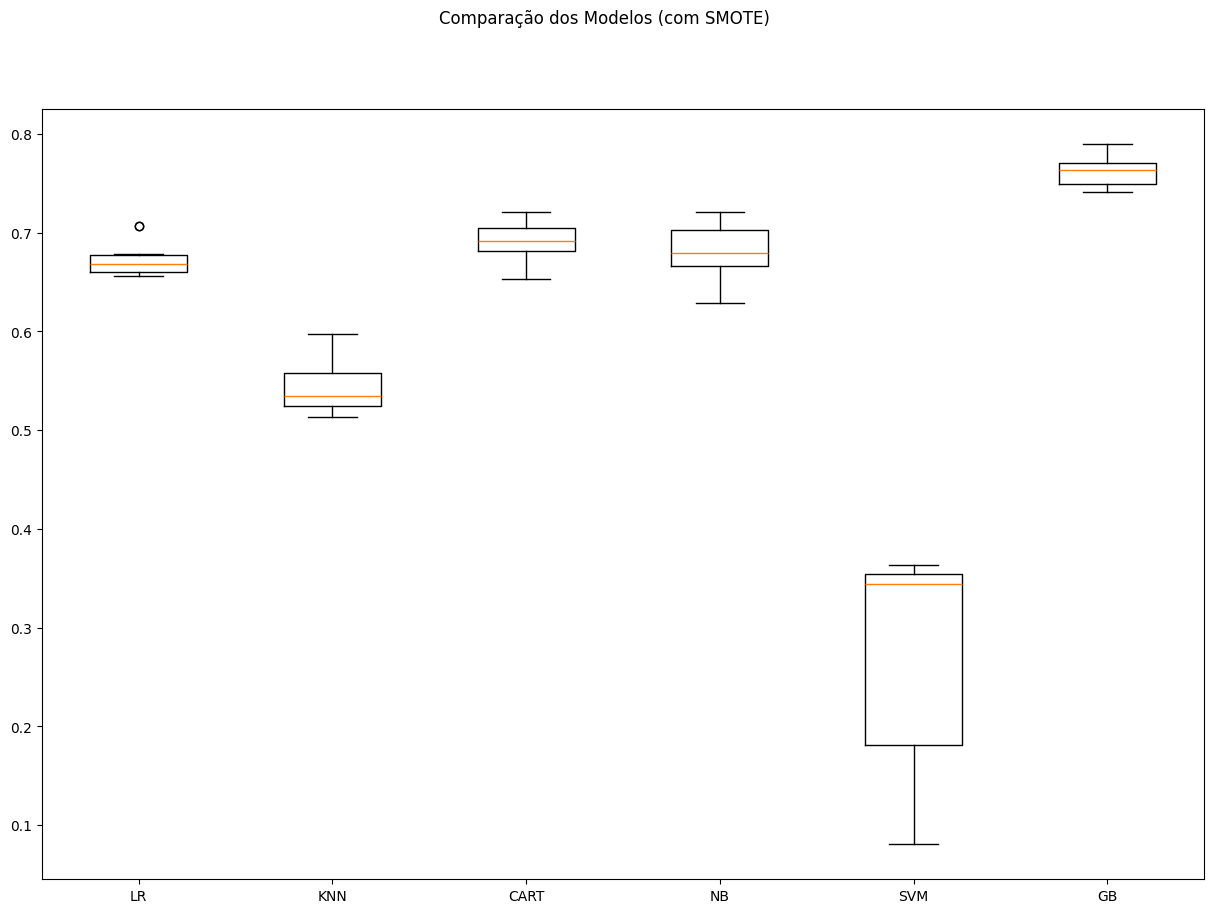

In [ ]:

base_models = []
num_trees = 100

base_models.append(('LR',   LogisticRegression(max_iter=200)))
base_models.append(('KNN',  KNeighborsClassifier()))
base_models.append(('CART', DecisionTreeClassifier()))
base_models.append(('NB',   GaussianNB()))
base_models.append(('SVM',  SVC(cache_size=500)))
base_models.append(('GB',   GradientBoostingClassifier(n_estimators=num_trees)))

smote_results = []
names = []

# Aplicaçao do SMOTE
for name, model in base_models:
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=seed)),
        ('model', model)
    ])
    smote_cv_results = cross_val_score(
        pipeline, X_train, y_train, cv=kfold, scoring=scoring,
        n_jobs=-1
    )
    smote_results.append(smote_cv_results)
    names.append(name)
    print(f"{name}: {smote_cv_results.mean():.3f} (+/- {smote_cv_results.std():.3f})")

# Boxplot
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Comparação dos Modelos (com SMOTE)')
ax = fig.add_subplot(111)
plt.boxplot(smote_results)
ax.set_xticklabels(names)
plt.show()

# Tabela comparativa Antes e Depois

In [26]:
# listas vazias para armazenar médias
medias_original = []
medias_smote = []

for valor in results:
    medias_original.append(valor.mean())

for valor in smote_results:
    medias_smote.append(valor.mean())

tabela_comparativa = pd.DataFrame({
    'Modelo':        names,
    'Sem SMOTE':     medias_original,
    'Com SMOTE':     medias_smote,
})

# coluna com diferença
tabela_comparativa['Δ'] = tabela_comparativa['Com SMOTE'] - tabela_comparativa['Sem SMOTE']

tabela_comparativa = tabela_comparativa.round(3)
tabela_comparativa

,Modelo,Sem SMOTE,Com SMOTE,Δ
0,LR,0.634,0.673,0.039
1,KNN,0.585,0.544,-0.040
2,CART,0.670,0.692,0.022
3,NB,0.674,0.681,0.007
4,SVM,0.333,0.279,-0.054
5,GB,0.759,0.761,0.002


### Criação e avaliação de modelos: dados padronizados e normalizados
#### usando o mesmo componente

LR-padr: 0.743 (0.013)
LR-norm: 0.737 (0.015)
LR-padr+smote: 0.748 (0.015)
LR-norm+smote: 0.742 (0.017)
KNN-padr: 0.683 (0.016)
KNN-norm: 0.655 (0.019)
KNN-padr+smote: 0.627 (0.029)
KNN-norm+smote: 0.611 (0.016)
CART-padr: 0.676 (0.023)
CART-norm: 0.668 (0.019)
CART-padr+smote: 0.679 (0.025)
CART-norm+smote: 0.674 (0.020)
NB-padr: 0.670 (0.014)
NB-norm: 0.670 (0.014)
NB-padr+smote: 0.680 (0.017)
NB-norm+smote: 0.670 (0.024)
SVM-padr: 0.743 (0.014)
SVM-norm: 0.729 (0.015)
SVM-padr+smote: 0.750 (0.020)
SVM-norm+smote: 0.745 (0.020)
GB-padr: 0.760 (0.011)
GB-norm: 0.759 (0.011)
GB-padr+smote: 0.760 (0.015)
GB-norm+smote: 0.758 (0.014)


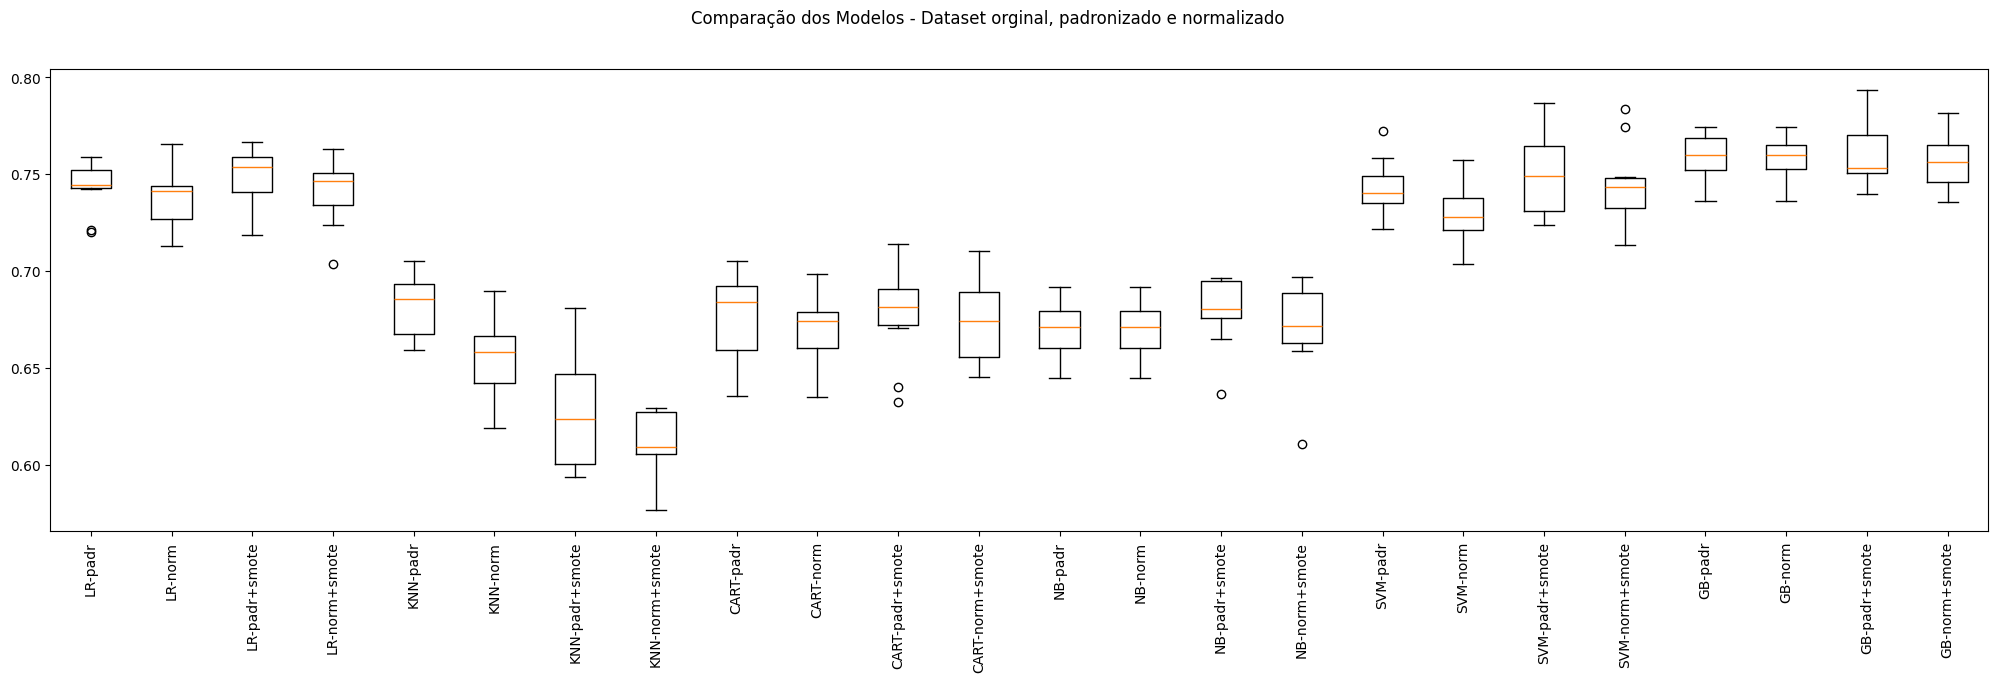

In [ ]:
np.random.seed(seed) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results_preprocessed = []
names = []

new_models = []

new_models.append(('LR',   LogisticRegression(max_iter=200)))
new_models.append(('KNN',  KNeighborsClassifier()))
new_models.append(('CART', DecisionTreeClassifier()))
new_models.append(('NB',   GaussianNB()))
new_models.append(('SVM',  SVC(cache_size=500)))
new_models.append(('GB',   GradientBoostingClassifier(n_estimators=num_trees)))


# Definindo os componentes do pipeline
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())
smote = ('SMOTE', SMOTE(random_state=seed))


# Criando pipelines para cada modelo
for name, model in new_models:
    pipelines.append((name + '-padr', Pipeline(steps=[standard_scaler, (name, model)])))
    pipelines.append((name + '-norm', Pipeline(steps=[min_max_scaler, (name, model)])))
    pipelines.append((name + '-padr+smote', ImbPipeline(steps=[standard_scaler, smote, (name, model)])))
    pipelines.append((name + '-norm+smote', ImbPipeline(steps=[min_max_scaler, smote, (name, model)])))


# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring, n_jobs=-1)
    results_preprocessed.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado') 
ax = fig.add_subplot(111) 
plt.boxplot(results_preprocessed) 
ax.set_xticklabels(names, rotation=90)
plt.show()


#### Criando componentes únicos para cada pipeline

LR-padr: 0.743 (0.013)
LR-norm: 0.737 (0.015)
LR-padr+smote: 0.748 (0.015)
LR-norm+smote: 0.742 (0.017)
KNN-padr: 0.683 (0.016)
KNN-norm: 0.655 (0.019)
KNN-padr+smote: 0.627 (0.029)
KNN-norm+smote: 0.611 (0.016)
CART-padr: 0.681 (0.020)
CART-norm: 0.677 (0.018)
CART-padr+smote: 0.673 (0.025)
CART-norm+smote: 0.678 (0.024)
NB-padr: 0.670 (0.014)
NB-norm: 0.670 (0.014)
NB-padr+smote: 0.680 (0.017)
NB-norm+smote: 0.670 (0.024)
SVM-padr: 0.743 (0.014)
SVM-norm: 0.729 (0.015)
SVM-padr+smote: 0.750 (0.020)
SVM-norm+smote: 0.745 (0.020)
GB-padr: 0.759 (0.012)
GB-norm: 0.759 (0.011)
GB-padr+smote: 0.761 (0.015)
GB-norm+smote: 0.758 (0.014)


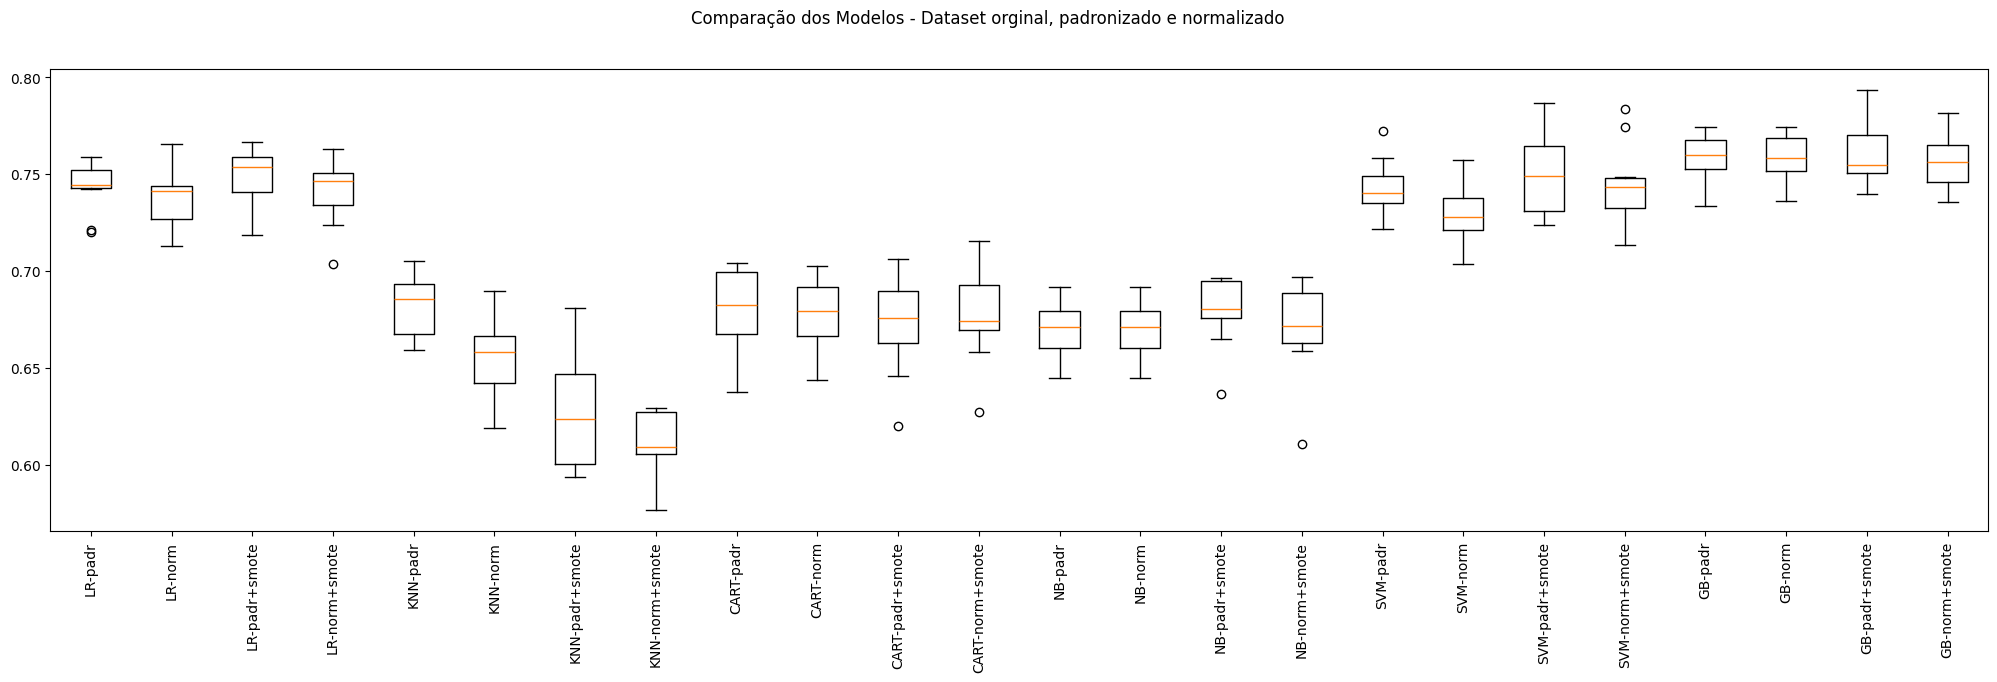

In [ ]:
np.random.seed(seed)

pipelines = []
results_preprocessed = []
names = []

new_models = []

new_models.append(('LR',   LogisticRegression(max_iter=200)))
new_models.append(('KNN',  KNeighborsClassifier()))
new_models.append(('CART', DecisionTreeClassifier()))
new_models.append(('NB',   GaussianNB()))
new_models.append(('SVM',  SVC(cache_size=500)))
new_models.append(('GB',   GradientBoostingClassifier(n_estimators=num_trees)))


# Definindo os componentes do pipeline
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
smote = ('SMOTE', SMOTE(random_state=seed))


# Criando pipelines para cada modelo
for name, model in new_models:
    pipelines.append((name + '-padr', Pipeline(steps=[('StandardScaler', clone(standard_scaler)), (name, model)])))
    pipelines.append((name + '-norm', Pipeline(steps=[('MinMaxScaler', clone(min_max_scaler)), (name, model)])))
    pipelines.append((name + '-padr+smote', ImbPipeline(steps=[('StandardScaler', clone(standard_scaler)), smote, (name, model)])))
    pipelines.append((name + '-norm+smote', ImbPipeline(steps=[('MinMaxScaler', clone(min_max_scaler)), smote, (name, model)])))


# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring, n_jobs=-1)
    results_preprocessed.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado') 
ax = fig.add_subplot(111) 
plt.boxplot(results_preprocessed) 
ax.set_xticklabels(names, rotation=90)
plt.show()


### Learning Curve
O quanto cada modelo pode ser melhorado com fine tunning?

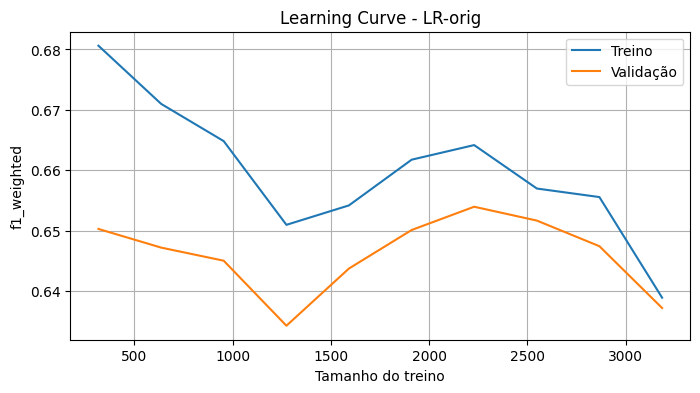

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

for name, model in pipelines:
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train, y_train,
        cv=kfold,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    plt.figure(figsize=(8, 4))
    plt.plot(train_sizes, train_scores.mean(axis=1), label='Treino')
    plt.plot(train_sizes, val_scores.mean(axis=1), label='Validação')
    plt.title(f'Learning Curve - {name}')
    plt.xlabel('Tamanho do treino')
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(True)
    plt.show()

    break

# Grid Search

## Todos os modelos

In [ ]:
np.random.seed(seed)

# Definindo os parâmetros para GridSearchCV
param_grids = {
    'LR': {
        'LR__C': [0.01, 0.1, 1, 10, 100],
        'LR__solver': ['liblinear', 'saga']
    },
    'KNN': {
        'KNN__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
        'KNN__metric': ["euclidean", "manhattan", "minkowski"]
    },
    'CART': {
        'CART__max_depth': [None, 10, 20, 30, 40, 50],
        'CART__min_samples_split': [2, 5, 10],
        'CART__min_samples_leaf': [1, 2, 4]
    },
    'NB': {
        'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'SVM': [
        {
            'SVM__kernel': ['linear'],
            'SVM__C': [0.1, 1, 10, 100]
        },
        {
            'SVM__kernel': ['rbf'],
            'SVM__C': [0.1, 1, 10, 100],
            'SVM__gamma': [1, 0.1, 0.01, 0.001]
        }
    ],
    'GB': {
        'GB__n_estimators': [10, 50, 100, 200],
        'GB__learning_rate': [0.01, 0.1, 0.2, 0.3],
        'GB__max_depth': [3, 5, 7, 9]
    }
}

# Parâmetros de cross-validation e scoring
scoring = 'f1_weighted'
kfold = 5

# Executando o GridSearchCV para cada pipeline
for name, pipeline in pipelines:
    model_type = name.split('-')[0]
    if model_type in param_grids:
        param_grid = param_grids[model_type]
    else:
        param_grid = {}  # Para modelos que não têm parâmetros definidos

    grid = GridSearchCV(
        estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=kfold,
        n_jobs=-1,
        refit=True,
        )
    grid.fit(X_train, y_train)
    # Imprimindo a melhor configuração
    print("Modelo: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

# 156 min
    

Modelo: LR-padr - Melhor: 0.744138 usando {'LR__C': 1, 'LR__solver': 'saga'}
Modelo: LR-norm - Melhor: 0.744289 usando {'LR__C': 10, 'LR__solver': 'saga'}
Modelo: LR-padr+smote - Melhor: 0.750983 usando {'LR__C': 1, 'LR__solver': 'saga'}
Modelo: LR-norm+smote - Melhor: 0.748837 usando {'LR__C': 100, 'LR__solver': 'saga'}
Modelo: KNN-padr - Melhor: 0.682657 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 5}
Modelo: KNN-norm - Melhor: 0.660544 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 5}
Modelo: KNN-padr+smote - Melhor: 0.649453 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 1}
Modelo: KNN-norm+smote - Melhor: 0.626038 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 1}
Modelo: CART-padr - Melhor: 0.719880 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 5}
Modelo: CART-norm - Melhor: 0.719278 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 5}
Modelo: CART-padr+smote - Melho

# Resultados Finais e Considerações - Escolhendo o melhor modelo

Modelo: GB-norm+smote - Melhor: 0.770126 usando {'GB__learning_rate': 0.2, 'GB__max_depth': 3, 'GB__n_estimators': 100}

Modelo: SVM-padr+smote - Melhor: 0.760531 usando {'SVM__C': 100, 'SVM__gamma': 0.001, 'SVM__kernel': 'rbf'}

Modelo: GB-padr+smote - Melhor: 0.766889 usando {'GB__learning_rate': 0.1, 'GB__max_depth': 7, 'GB__n_estimators': 200}

## Avaliando o desempenho do modelo com os dados de teste
Modelo: GB-norm+smote - Melhor: 0.770126 usando {'GB__learning_rate': 0.2, 'GB__max_depth': 3, 'GB__n_estimators': 100}

In [ ]:
from sklearn.metrics import classification_report

best_model = GradientBoostingClassifier(
    learning_rate=0.2,
    max_depth=3,
    n_estimators=100,
    random_state=seed
)
scaler = ('MinMaxScaler', MinMaxScaler())
smote = ('SMOTE', SMOTE(random_state=seed))

best_pipeline = ImbPipeline(steps=[
                    scaler,
                    smote,
                    ('GB', best_model)
                    ])


best_pipeline.fit(X_train, y_train)


predictions = best_pipeline.predict(X_test)
print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7638496412104344
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.54      0.47      0.50       159
    Graduate       0.82      0.88      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.76      0.77      0.76       885



## Teste 2 (descartado)
Modelo: SVM-padr+smote - Melhor: 0.760531 usando {'SVM__C': 100, 'SVM__gamma': 0.001, 'SVM__kernel': 'rbf'}

In [30]:
from sklearn.metrics import classification_report

np.random.seed(seed)

best_model = SVC(
    C=100,
    gamma=0.001,
    kernel='rbf'
)

best_pipeline = ImbPipeline(steps=[
                    ('StandardScaler', StandardScaler()),
                    ('SMOTE', SMOTE(random_state=seed)),
                    ('SVM', best_model)
                    ])


best_pipeline.fit(X_train, y_train)


predictions = best_pipeline.predict(X_test)
print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7685149899479996
              precision    recall  f1-score   support

     Dropout       0.86      0.72      0.78       284
    Enrolled       0.47      0.67      0.55       159
    Graduate       0.86      0.82      0.84       442

    accuracy                           0.76       885
   macro avg       0.73      0.73      0.72       885
weighted avg       0.79      0.76      0.77       885



## Teste 3 (descartado)

Modelo: GB-padr+smote - Melhor: 0.766889 usando {'GB__learning_rate': 0.1, 'GB__max_depth': 7, 'GB__n_estimators': 200}

In [41]:
from sklearn.metrics import classification_report

best_model = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    random_state=seed
)

best_pipeline = ImbPipeline(steps=[
                    ('StandardScaler', StandardScaler()),
                    ('SMOTE', SMOTE(random_state=seed)),
                    ('GB', best_model)
                    ])


best_pipeline.fit(X_train, y_train)


predictions = best_pipeline.predict(X_test)
print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7644392566429468
              precision    recall  f1-score   support

     Dropout       0.79      0.76      0.78       284
    Enrolled       0.57      0.45      0.50       159
    Graduate       0.81      0.89      0.85       442

    accuracy                           0.77       885
   macro avg       0.73      0.70      0.71       885
weighted avg       0.76      0.77      0.76       885



# Salvando

In [36]:
# Salvando o modelo
model_filename = 'gb_students_classifier.pkl'
with open("../models/"+model_filename, 'wb') as file:
    pickle.dump(best_model, file)

# Salvando o scaler
scaler_filename = 'minmax_scaler_students.pkl'
with open("../models/"+scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
    
# Salvando o pipeline
pipeline_filename = 'rf_diabetes_pipeline.pkl'
with open("../models/"+pipeline_filename, 'wb') as file:
    pickle.dump(best_pipeline, file)
    
# Salvando X_test e y_test
X_test_df = pd.DataFrame(X_test, columns=students_dataframe.columns[:-1])
y_test_df = pd.DataFrame(y_test, columns=[students_dataframe.columns[-1]])
X_test_df.to_csv("data/X_test_dataset_students.csv", index=False)
y_test_df.to_csv("data/y_test_dataset_students.csv", index=False)

# Simulando a aplicação do modelo em dados não vistos

In [56]:
dados_in = [[
    2, 39, 1, 8014, 0, 1, 100.0, 1, 37, 38, 9, 9, 141.5, 
    0, 0, 0, 1, 0, 0, 45, 0, 0, 6, 9, 5, 12.334, 0, 0, 
    6, 6, 6, 13.0, 0, 13.9, -0.3, 0.79
]]

dados_in_array = np.array(dados_in)
nova_predicao = best_pipeline.predict(dados_in_array)
probabilidades = best_pipeline.predict_proba(dados_in_array)


print(f"A categoria prevista para o aluno é: {nova_predicao[0]}")
print(f"As probabilidades para cada classe são: {probabilidades[0]}")

A categoria prevista para o aluno é: Graduate
As probabilidades para cada classe são: [0.05626962 0.05630812 0.88742226]
